<a href="https://colab.research.google.com/github/Kryptera-K/LRCX-BB-KC-Squeeze-Momentum-Startegy/blob/main/LRCX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install vectorbt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.7/527.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import vectorbt as vbt

# -------------------------
# Download Data
# -------------------------

symbol = "LRCX"
start_date = "2000-01-01"
end_date = "2026-01-01"
interval = "1d"

df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
df.to_csv("LRCX_clean.csv", index=False)
df

/tmp/ipython-input-3204758165.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,3.189235,3.235353,2.877052,3.206973,31839000
2000-01-04,3.050881,3.164403,3.011858,3.099660,32958000
2000-01-05,3.006537,3.093451,2.916075,3.036691,30948000
2000-01-06,2.985251,3.093450,2.923169,2.974608,26421000
2000-01-07,3.029595,3.043786,2.823839,2.994121,36846000
...,...,...,...,...,...
2025-10-13,137.809998,138.899994,136.580002,138.089996,10048100
2025-10-14,138.309998,140.919998,134.039993,134.100006,10509700
2025-10-15,144.779999,145.220001,141.100006,144.000000,9722700


In [ ]:
# -------------------------
# Necessary Parameters
# -------------------------

BB_PERIOD = 20
BB_SHIFT = 5
BB_STD = 2
KC_MULTIPLIER = 2
KC_PERIOD = 20
KC_SHIFT = 5
WR_LEVEL = -50
WR_PERIOD = 14

# -------------------------
# Indicator Functions
# -------------------------

def bb_squeeze(df, period=BB_PERIOD, std_multiplier=BB_STD, shift=BB_SHIFT):
    """
    Detect Bollinger Band Squeeze (bands narrowing)
    """
    df = calculate_bollinger_bands(df, period, std_multiplier)
    bandwidth = df['BB_Upper'] - df['BB_Lower']
    return bandwidth < bandwidth.shift(shift)


def calculate_bollinger_bands(df, period=BB_PERIOD, std_multiplier=BB_STD):
    """
    Calculate Bollinger Bands: Middle, Upper, and Lower.
    """
    df = df.copy()
    df['BB_MA'] = df['Close'].rolling(window=period).mean()
    df['BB_Upper'] = df['BB_MA'] + std_multiplier * df['Close'].rolling(window=period).std()
    df['BB_Lower'] = df['BB_MA'] - std_multiplier * df['Close'].rolling(window=period).std()
    return df


def kc_upper_band_falling(df, shift=KC_SHIFT):
    df = calculate_keltner_channel(df)
    return df['KC_Upper'] < df['KC_Upper'].shift(shift)


def calculate_keltner_channel(df, period=KC_PERIOD, multiplier=KC_MULTIPLIER):
    """
    Calculate Keltner Channel (Mid, Upper, Lower) and ATR.
    """
    df = df.copy()

    # Typical Price
    df['TP'] = (df['High'] + df['Low'] + df['Close']) / 3

    # EMA of Typical Price
    df['KC_Mid'] = df['TP'].ewm(span=period, adjust=False).mean()

    # True Range and ATR
    df['H-L'] = df['High'] - df['Low']
    df['H-PC'] = abs(df['High'] - df['Close'].shift(1))
    df['L-PC'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['H-L','H-PC','L-PC']].max(axis=1)
    df['ATR'] = df['TR'].rolling(period).mean()

    # Upper and Lower Bands
    df['KC_Upper'] = df['KC_Mid'] + multiplier * df['ATR']
    df['KC_Lower'] = df['KC_Mid'] - multiplier * df['ATR']

    return df


def kc_open_above_upper(df):
    df = calculate_keltner_channel(df)
    return df['Open'] > df['KC_Upper']


def wr_change_direction_upward(df):
    df = calculate_williams_r(df)
    wr_diff = df['Williams_%R'].diff()
    return (wr_diff > 0) & (wr_diff.shift(1) < 0)


def calculate_williams_r(df, period=WR_PERIOD):
    highest_high = df['High'].rolling(window=period).max()
    lowest_low = df['Low'].rolling(window=period).min()
    df['Williams_%R'] = -100 * (highest_high - df['Close']) / (highest_high - lowest_low)
    return df



# -------------------------
# Entry conditions
# -------------------------

df["BB_Squeeze"] = bb_squeeze(df)
df["KC_Upper_Band_Falling"] = kc_upper_band_falling(df)

# -------------------------
# Exit conditions
# -------------------------

df["KC_Open_Above_Upper"] = kc_open_above_upper(df)
df["WR_Change_Direction_Upward"] = wr_change_direction_upward(df)

# -------------------------
# Signals
# -------------------------

entry_conditions = [
    'BB_Squeeze',
    'KC_Upper_Band_Falling',
]
exit_conditions = [
    'KC_Open_Above_Upper',
    'WR_Change_Direction_Upward',
]

df['entry_signal'] = df[entry_conditions].all(axis=1)
df['exit_signal']  = df[exit_conditions].all(axis=1)

# -------------------------
# Backtest
# -------------------------


shift_entries = df['entry_signal'].shift(1).astype(bool).fillna(False).to_numpy()
shift_exits = df['exit_signal'].shift(1).astype(bool).fillna(False).to_numpy()

pf = vbt.Portfolio.from_signals(
    close=df['Open'],
    entries=shift_entries,
    exits=shift_exits,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='1d'
)


# -------------------------
# Portfolio Stats / Plot
# -------------------------

print(pf.stats())
pf.plot().show()

Start                                2000-01-03 00:00:00
End                                  2025-10-17 00:00:00
Period                                6488 days 00:00:00
Start Value                                     100000.0
End Value                                10846482.907023
Total Return [%]                            10746.482907
Benchmark Return [%]                         4335.958658
Max Gross Exposure [%]                             100.0
Total Fees Paid                             208590.16848
Max Drawdown [%]                               85.280207
Max Drawdown Duration                 1390 days 00:00:00
Total Trades                                          58
Total Closed Trades                                   58
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                   84.482759
Best Trade [%]                                 45.349958
Worst Trade [%]                

In [ ]:
# Buy and Hold Performance Metrics
df_holding = df['Open']
pf_holding = vbt.Portfolio.from_holding(df_holding, init_cash=100_000 , freq='D')
print(pf_holding.stats())

Start                         2000-01-03 00:00:00
End                           2025-10-17 00:00:00
Period                         6488 days 00:00:00
Start Value                              100000.0
End Value                          4435958.657998
Total Return [%]                      4335.958658
Benchmark Return [%]                  4335.958658
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        88.206818
Max Drawdown Duration          1825 days 00:00:00
Total Trades                                    1
Total Closed Trades                             0
Total Open Trades                               1
Open Trade PnL                     4335958.657998
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]                          NaN


/tmp/ipython-input-3006420751.py:14: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


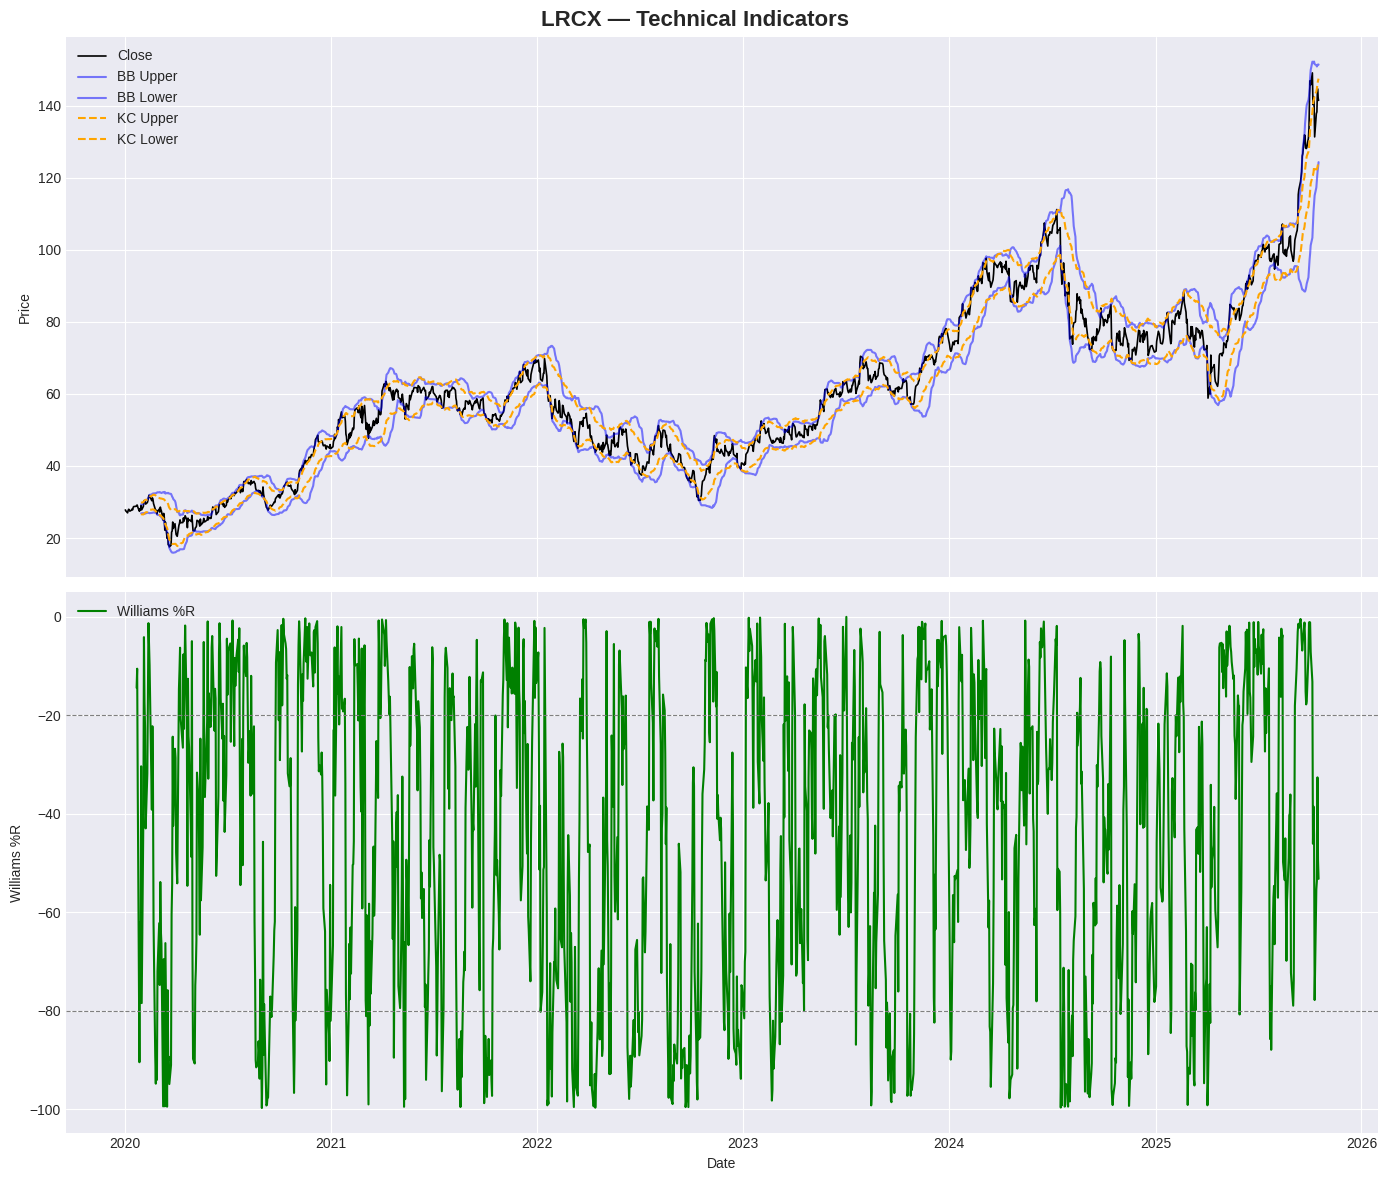

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# -------------------------
# Download Data
# -------------------------
symbol = "LRCX"
start_date = "2020-01-01"
end_date = "2026-01-01"
interval = "1d"

df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
df.dropna(inplace=True)

# -------------------------
# Parameters
# -------------------------
BB_PERIOD = 20
BB_SHIFT = 5
BB_STD = 2
KC_MULTIPLIER = 2
KC_PERIOD = 20
KC_SHIFT = 5
WR_LEVEL = -50
WR_PERIOD = 14

# -------------------------
# Indicator Calculations
# -------------------------
def calculate_bollinger_bands(df, period=BB_PERIOD, std_multiplier=BB_STD):
    df['BB_MA'] = df['Close'].rolling(window=period).mean()
    df['BB_STD'] = df['Close'].rolling(window=period).std()
    df['BB_Upper'] = df['BB_MA'] + std_multiplier * df['BB_STD']
    df['BB_Lower'] = df['BB_MA'] - std_multiplier * df['BB_STD']
    return df

def calculate_keltner_channel(df, period=KC_PERIOD, multiplier=KC_MULTIPLIER):
    tp = (df['High'] + df['Low'] + df['Close']) / 3
    df['KC_Mid'] = tp.ewm(span=period, adjust=False).mean()
    df['H-L'] = df['High'] - df['Low']
    df['H-PC'] = abs(df['High'] - df['Close'].shift(1))
    df['L-PC'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['H-L', 'H-PC', 'L-PC']].max(axis=1)
    df['ATR'] = df['TR'].rolling(period).mean()
    df['KC_Upper'] = df['KC_Mid'] + multiplier * df['ATR']
    df['KC_Lower'] = df['KC_Mid'] - multiplier * df['ATR']
    return df

def calculate_williams_r(df, period=WR_PERIOD):
    highest_high = df['High'].rolling(window=period).max()
    lowest_low = df['Low'].rolling(window=period).min()
    df['Williams_%R'] = -100 * (highest_high - df['Close']) / (highest_high - lowest_low)
    return df

# -------------------------
# Add All Indicators
# -------------------------
df = calculate_bollinger_bands(df)
df = calculate_keltner_channel(df)
df = calculate_williams_r(df)

# Derived indicator conditions
bandwidth = df['BB_Upper'] - df['BB_Lower']
df['BB_Squeeze'] = bandwidth < bandwidth.shift(BB_SHIFT)
df['KC_Upper_Falling'] = df['KC_Upper'] < df['KC_Upper'].shift(KC_SHIFT)
df['WR_Change_Up'] = (df['Williams_%R'].diff() > 0) & (df['Williams_%R'].diff().shift(1) < 0)

# -------------------------
# Plot Section
# -------------------------
plt.style.use("seaborn-v0_8-darkgrid")

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f"{symbol} — Technical Indicators", fontsize=16, fontweight='bold')

# === Plot 1: Price + Bollinger Bands + Keltner Channel ===
axes[0].plot(df.index, df['Close'], label='Close', color='black', linewidth=1.2)
axes[0].plot(df.index, df['BB_Upper'], label='BB Upper', color='blue', alpha=0.5)
axes[0].plot(df.index, df['BB_Lower'], label='BB Lower', color='blue', alpha=0.5)
axes[0].plot(df.index, df['KC_Upper'], label='KC Upper', color='orange', linestyle='--')
axes[0].plot(df.index, df['KC_Lower'], label='KC Lower', color='orange', linestyle='--')

axes[0].set_ylabel("Price")
axes[0].legend(loc='upper left')

# === Plot 3: Williams %R ===
axes[1].plot(df.index, df['Williams_%R'], label='Williams %R', color='green')
axes[1].axhline(-20, color='gray', linestyle='--', linewidth=0.8)
axes[1].axhline(-80, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_ylabel("Williams %R")
axes[1].set_xlabel("Date")
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()
